In [7]:
import numpy as np
import pandas as pd
import os, shutil, pathlib
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize

In [8]:
p = Path().cwd()
q = p.joinpath('archive', 'train')

target_dict = {'Closed' : 0, 'Open' : 1, 'no_yawn' : 2, 'yawn' : 3}

images = [] # create an empty list
labels = [] # create an empty list

for fldr in q.iterdir(): 
    current_label = fldr.name
    for img in fldr.iterdir():
        img = load_img(img) 
        img_array =  img_to_array(img) # convert the image to an NumPy array 
        img_array_resized =  smart_resize(img_array, (128, 128)) # if necessary, resize the image to 128 by 128 
        img_array_reshaped = img_array_resized.reshape(128, 128, 3) # reshape  image to (height, width, 3) from (height, width)
        images.append(img_array_reshaped) # add reshaped image to list of images 
        labels.append(target_dict[current_label]) # add label for this image to the list of labels 

In [9]:
images = np.array(images) # convert the list of images to a NumPy array 
labels = np.array(labels) # convert the list of labels to a NumPy array

In [10]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels) # use the target_dict to convert the string labels to an array of integers

In [11]:
# Normalising the Images data - Divide by 255 in order to get the pixel values between 0 - 1.

images = images.astype('float32') / 255

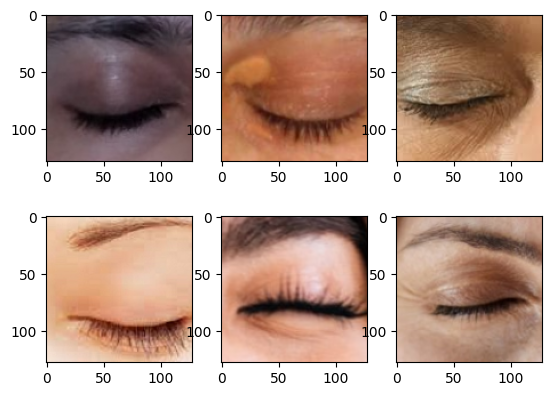

In [13]:
# Displaying the first 6 train_images

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
plt.show()

# From scratch

In [14]:
from sklearn.model_selection import train_test_split
train_images, test_images, train_labels, test_labels  = train_test_split(images,labels, test_size=0.1)
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.2)

In [15]:
print(f'train_images : ',train_images.shape)
print(f'valid_images : ',valid_images.shape)
print(f'test_images  : ',test_images.shape)
print('-------------------------------')
print(f'train_labels : ',train_labels.shape)
print(f'valid_labels : ',valid_labels.shape)
print(f'test_labels  : ',test_labels.shape)

train_images :  (2088, 128, 128, 3)
valid_images :  (522, 128, 128, 3)
test_images  :  (290, 128, 128, 3)
-------------------------------
train_labels :  (2088, 4)
valid_labels :  (522, 4)
test_labels  :  (290, 4)


In [16]:
# Importing the required Libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

# Building a Baseline Model

In [17]:
#1. Constructing a CNN Model Network
Baseline_model = Sequential([
    Conv2D(filters = 32, kernel_size=(3,3),activation='relu', padding = 'same', input_shape=(128,128,3)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(20, activation = 'relu'),
    Dense(4, activation = 'softmax')])

#2. Compiling the Model
Baseline_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

#3. Fitting the Model
Baseline_model.fit(train_images,train_labels, epochs=12, validation_data=(valid_images,valid_labels), batch_size=64)
test_loss, test_acc = Baseline_model.evaluate(test_images, test_labels)
print('\nTest Accuracy:', test_acc, '\nTest Loss', test_loss)

Epoch 1/12
33/33 [==============================] - 6s 157ms/step - loss: 1.5810 - accuracy: 0.3233 - val_loss: 1.1782 - val_accuracy: 0.5057
Epoch 2/12
33/33 [==============================] - 6s 171ms/step - loss: 1.1338 - accuracy: 0.4794 - val_loss: 1.1011 - val_accuracy: 0.5000
Epoch 3/12
33/33 [==============================] - 5s 152ms/step - loss: 1.0588 - accuracy: 0.4938 - val_loss: 1.0552 - val_accuracy: 0.5192
Epoch 4/12
33/33 [==============================] - 5s 159ms/step - loss: 1.0324 - accuracy: 0.4880 - val_loss: 1.0317 - val_accuracy: 0.5153
Epoch 5/12
33/33 [==============================] - 5s 143ms/step - loss: 1.0133 - accuracy: 0.4947 - val_loss: 1.0097 - val_accuracy: 0.5192
Epoch 6/12
33/33 [==============================] - 5s 143ms/step - loss: 0.9911 - accuracy: 0.5010 - val_loss: 0.9965 - val_accuracy: 0.4904
Epoch 7/12
33/33 [==============================] - 5s 151ms/step - loss: 0.9761 - accuracy: 0.5134 - val_loss: 0.9822 - val_accuracy: 0.5230
Epoch 

# Data Augumentation

### Import Required Libraries

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
#1. Constructing a CNN Model Network

# CN Network
Final_model = Sequential([
    Conv2D(filters = 64, kernel_size=(3,3),activation='relu', padding = 'same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
#    Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same'),
#    BatchNormalization(),
#    MaxPooling2D(pool_size=(2,2)),
    
# Dense Network    
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.03),
#    Dense(64, activation = 'relu'),
    Dense(4, activation = 'softmax')])

#2. Compiling the Model
opt=Adam(learning_rate=0.001)
Final_model.compile(optimizer=opt, loss = 'categorical_crossentropy', metrics = ['accuracy'])


#3. Fitting the Model
callbacks = ModelCheckpoint(filepath="convnet_from_scratch.keras", save_best_only=True, monitor="val_loss")

data_augmentation = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, 
                                       zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

Final_output = Final_model.fit(data_augmentation.flow(train_images,train_labels, batch_size=32), epochs=12, 
                               validation_data=(valid_images,valid_labels), batch_size=32, callbacks=[callbacks])

test_loss, test_acc = Final_model.evaluate(test_images, test_labels)

print('\nTest Accuracy:', test_acc, '\nTest Loss   :', test_loss)

Epoch 1/12
66/66 [==============================] - 27s 394ms/step - loss: 8.0581 - accuracy: 0.5666 - val_loss: 1.7184 - val_accuracy: 0.4023
Epoch 2/12
66/66 [==============================] - 25s 383ms/step - loss: 0.6502 - accuracy: 0.6887 - val_loss: 1.8824 - val_accuracy: 0.4215
Epoch 3/12
66/66 [==============================] - 27s 410ms/step - loss: 0.6016 - accuracy: 0.6810 - val_loss: 2.1673 - val_accuracy: 0.4291
Epoch 4/12
66/66 [==============================] - 49s 744ms/step - loss: 0.5658 - accuracy: 0.7035 - val_loss: 0.8851 - val_accuracy: 0.6322
Epoch 5/12
66/66 [==============================] - 62s 943ms/step - loss: 0.5737 - accuracy: 0.7112 - val_loss: 0.6312 - val_accuracy: 0.7701
Epoch 6/12
66/66 [==============================] - 59s 887ms/step - loss: 0.5459 - accuracy: 0.7308 - val_loss: 0.5170 - val_accuracy: 0.7318
Epoch 7/12
66/66 [==============================] - 56s 842ms/step - loss: 0.5358 - accuracy: 0.7246 - val_loss: 0.5177 - val_accuracy: 0.7452

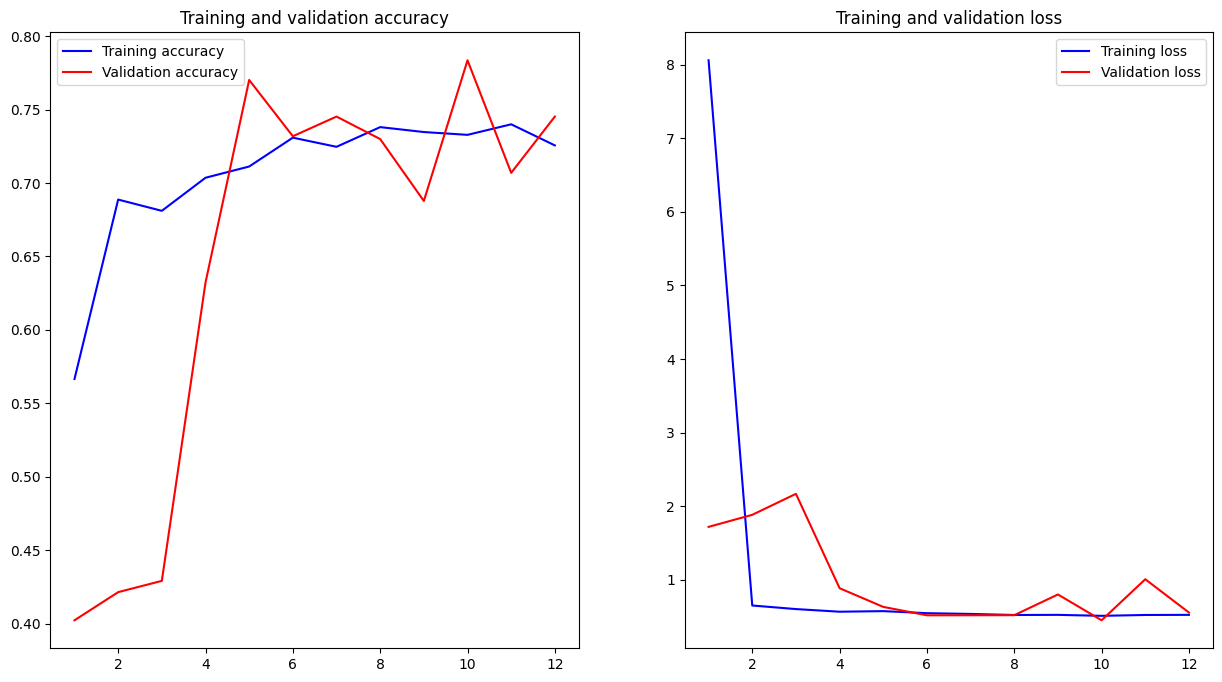

In [20]:
accuracy = Final_output.history["accuracy"]
val_accuracy = Final_output.history["val_accuracy"]

loss = Final_output.history["loss"]
val_loss = Final_output.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# Building a Final Model

In [21]:
#1. Constructing a CNN Model Network

# CN Network
Final_model = Sequential([
    Conv2D(filters = 64, kernel_size=(3,3),activation='relu', padding = 'same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
# Dense Network    
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.03),
    Dense(64, activation = 'relu'),
    Dense(4, activation = 'softmax')])

#2. Compiling the Model
#opt=Adam(learning_rate=0.003)
Final_model.compile(optimizer=Adam(learning_rate=0.003), loss = 'categorical_crossentropy', metrics = ['accuracy'])


#3. Fitting the Model
callbacks = ModelCheckpoint(filepath="convnet_from_scratch.keras", save_best_only=True, monitor="val_loss")

Final_output = Final_model.fit(train_images,train_labels, epochs=25, validation_data=(valid_images,valid_labels), batch_size=32,
                               callbacks=[callbacks])
test_loss, test_acc = Final_model.evaluate(test_images, test_labels)
print('\nTest Accuracy:', test_acc, '\nTest Loss   :', test_loss)

Epoch 1/25
66/66 [==============================] - 24s 351ms/step - loss: 6.1260 - accuracy: 0.6767 - val_loss: 23.9246 - val_accuracy: 0.3448
Epoch 2/25
66/66 [==============================] - 22s 336ms/step - loss: 3.2594 - accuracy: 0.7270 - val_loss: 13.4118 - val_accuracy: 0.3448
Epoch 3/25
66/66 [==============================] - 23s 343ms/step - loss: 1.2352 - accuracy: 0.7591 - val_loss: 13.9792 - val_accuracy: 0.3774
Epoch 4/25
66/66 [==============================] - 23s 347ms/step - loss: 1.1858 - accuracy: 0.7792 - val_loss: 9.1563 - val_accuracy: 0.4655
Epoch 5/25
66/66 [==============================] - 23s 347ms/step - loss: 0.5523 - accuracy: 0.8132 - val_loss: 1.4807 - val_accuracy: 0.6877
Epoch 6/25
66/66 [==============================] - 24s 360ms/step - loss: 0.5264 - accuracy: 0.8338 - val_loss: 6.3178 - val_accuracy: 0.4981
Epoch 7/25
66/66 [==============================] - 22s 333ms/step - loss: 0.3295 - accuracy: 0.8511 - val_loss: 0.8345 - val_accuracy: 0.7

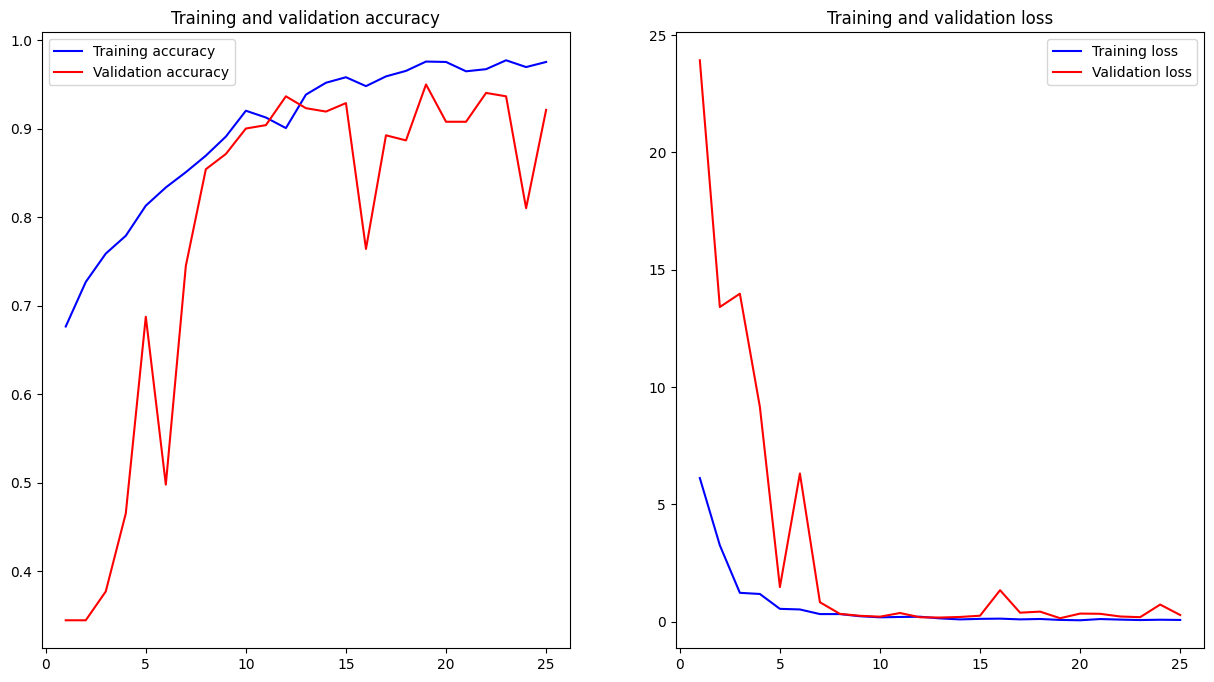

In [22]:
import matplotlib.pyplot as plt

accuracy = Final_output.history["accuracy"]
val_accuracy = Final_output.history["val_accuracy"]

loss = Final_output.history["loss"]
val_loss = Final_output.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
from tabulate import tabulate

# Sample data in the form of a list of lists
data = [
    ["Baseline CNN",96.93,91.78,1,2622398,12,64],
    ["Improved CNN",84.58,80.21,2,33556866,12,32],
    ["Finalized CNN",99.43,93.15,2,4223458,25,32],
    
]

# Table headers
headers = ["Model", "Accuracy(Train-in%)","Accuracy(Test-in%)","Total layers","Total params","epoch","batch size"]

print(tabulate(data, headers=headers))

Eye Blink Detection using OpenCV and Dlib

In [33]:
pip install face_recognition


[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



     -------------------------------------- 100.1/100.1 MB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached click-8.1.3-py3-none-any.whl (96 kB)
  Using cached dlib-19.24.1.tar.gz (3.2 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for dlib: filename=dlib-19.24.1-cp311-cp311-win_amd64.whl size=2825707 sha256=a1e1f9f67460afb7722a76042d00702f95adda59c6ff329d65a8bd4ff97afcf4
  Stored in directory: c:\users\15199\appdata\local\pip\cache\wheels\0a\7f\eb\c8ae742ad94109f000f0e2ed74c291694894bdd2dac534ccfd
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566185 sha256=7a7074ac7037fa05dc87a722d33050011395bb8e628e38528eb7fbcd5a1b94a9
  Stored in directory: c:\users\15199\appdata\local\pip\cache\wheels\65\6c\22\72e731c94d86e4ab268c2606d5dcef19cc6135df3613502c12
Successful

In [35]:
import face_recognition

In [36]:
pip install cmake

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
pip install dlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
pip install imutils

Note: you may need to restart the kernel to use updated packages.Collecting imutils
  Using cached imutils-0.5.4.tar.gz (17 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25855 sha256=515425dfbca40a702f422d02acc467ab2ae7f82585a57de9e5937dcf8c839b2c
  Stored in directory: c:\users\15199\appdata\local\pip\cache\wheels\95\13\03\eb9401614fdf049b74f5986b23698b20bba38ecdc1db65ae8d
Successfully built imutils




[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
pip install opencv-python numpy dlib imutils

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
cam = cv2.VideoCapture(0)
while True:
    _, frame = cam.read()
    cv2.imshow('Camera Feed', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cam.release()

KeyboardInterrupt: 

: 

In [1]:
# Importing the required dependencies
import cv2  # for video rendering
import dlib  # for face and landmark detection
import imutils

In [2]:
# for calculating dist b/w the eye landmarks
from scipy.spatial import distance as dist
# to get the landmark ids of the left and right eyes
from imutils import face_utils
  
# from imutils import

In [1]:
cam = cv2.VideoCapture('assets/my_blink.mp4')

# Initializing the Models for Landmark and face Detection
detector = dlib.get_frontal_face_detector()
landmark_predict = dlib.shape_predictor('C:/Users/15199/Capstone/Capstone Project/Capstone-Project---Group-3/shape_predictor_68_face_landmarks.dat')
  
while 1:
  
    # If the video is finished then reset it to the start
    if cam.get(cv2.CAP_PROP_POS_FRAMES) == cam.get(
      cv2.CAP_PROP_FRAME_COUNT):
        cam.set(cv2.CAP_PROP_POS_FRAMES, 0)
  
    else:
        _, frame = cam.read()
        frame = imutils.resize(frame, width=640)
  
        # converting frame to gray scale to pass to detector
        img_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
          
        # detecting the faces
        faces = detector(img_gray)
        for face in faces:
            cv2.rectangle(frame, face[0], face[1],
                          (200, 0, 0), 1)
  
        cv2.imshow("Video", frame)
        if cv2.waitKey(5) & 0xFF == ord('q'):
            break
  
cam.release()
cv2.destroyAllWindows()

NameError: name 'cv2' is not defined

In [ ]:
import cv2, dlib
import numpy as np
from imutils import face_utils
from tensorflow.keras.models import load_model
import winsound

IMG_SIZE = (64,56)
B_SIZE = (34, 26)
margin = 95
class_labels = ['center','left', 'right'] 
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')

font_letter = cv2.FONT_HERSHEY_PLAIN
model = load_model('models/gazev3.1.h5')
model_b = load_model('models/blinkdetection.h5')


def detect_gaze(eye_img):
    pred_l = model.predict(eye_img)
    accuracy = int(np.array(pred_l).max() * 100)
    gaze = class_labels[np.argmax(pred_l)]
    return gaze


def detect_blink(eye_img):
    pred_B = model_b.predict(eye_img)
    status = pred_B[0][0]
    status = status*100
    status = round(status,3)
    return  status

   
def crop_eye(img, eye_points):
    x1, y1 = np.amin(eye_points, axis=0)
    x2, y2 = np.amax(eye_points, axis=0)
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

    w = (x2 - x1) * 1.2
    h = w * IMG_SIZE[1] / IMG_SIZE[0]

    margin_x, margin_y = w / 2, h / 2

    min_x, min_y = int(cx - margin_x), int(cy - margin_y)
    max_x, max_y = int(cx + margin_x), int(cy + margin_y)

    eye_rect = np.rint([min_x, min_y, max_x, max_y]).astype(np.int)

    eye_img = gray[eye_rect[1]:eye_rect[3], eye_rect[0]:eye_rect[2]]

    return eye_img, eye_rect

# main
cap = cv2.VideoCapture(0)
# pattern = []
# frames = 10
# pattern_length = 0
frames_to_blink = 6
blinking_frames = 0
while cap.isOpened():
    output = np.zeros((900,820,3), dtype="uint8")
    ret, img = cap.read()
    img = cv2.flip(img,flipCode = 1)
    h,w = (112,128)	
    if not ret:
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    

    faces = detector(gray)

    for face in faces:
        shapes = predictor(gray, face)
        

        for n in range(36,42):
            x= shapes.part(n).x
            y = shapes.part(n).y
            next_point = n+1
            if n==41:
                next_point = 36 
            
            x2 = shapes.part(next_point).x
            y2 = shapes.part(next_point).y
            cv2.line(img,(x,y),(x2,y2),(0,69,255),2)

        for n in range(42,48):
            x= shapes.part(n).x
            y = shapes.part(n).y
            next_point = n+1
            if n==47:
                next_point = 42 
            
            x2 = shapes.part(next_point).x
            y2 = shapes.part(next_point).y
            cv2.line(img,(x,y),(x2,y2),(153,0,153),2)
        shapes = face_utils.shape_to_np(shapes)
        #~~~~~~~~~~~~~~~~~56,64 EYE IMAGE~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
        eye_img_l, eye_rect_l = crop_eye(gray, eye_points=shapes[36:42])
        eye_img_r, eye_rect_r = crop_eye(gray, eye_points=shapes[42:48])
        #~~~~~~~~~~~~~~~~FOR THE EYE FINAL_WINDOW~~~~~~~~~~~~~~~~~~~~~~#
        eye_img_l_view = cv2.resize(eye_img_l, dsize=(128,112))
        eye_img_l_view = cv2.cvtColor(eye_img_l_view,cv2.COLOR_BGR2RGB)
        eye_img_r_view = cv2.resize(eye_img_r, dsize=(128,112))
        eye_img_r_view = cv2.cvtColor(eye_img_r_view, cv2.COLOR_BGR2RGB)
        #~~~~~~~~~~~~~~~~~FOR THE BLINK DETECTION~~~~~~~~~~~~~~~~~~~~~~~
        eye_blink_left = cv2.resize(eye_img_l.copy(), B_SIZE)
        eye_blink_right = cv2.resize(eye_img_r.copy(), B_SIZE)
        eye_blink_left_i = eye_blink_left.reshape((1, B_SIZE[1], B_SIZE[0], 1)).astype(np.float32) / 255.
        eye_blink_right_i = eye_blink_right.reshape((1, B_SIZE[1], B_SIZE[0], 1)).astype(np.float32) / 255.
        #~~~~~~~~~~~~~~~~FOR THE GAZE DETECTIOM~~~~~~~~~~~~~~~~~~~~~~~~#
        eye_img_l = cv2.resize(eye_img_l, dsize=IMG_SIZE)
        eye_input_g = eye_img_l.copy().reshape((1, IMG_SIZE[1], IMG_SIZE[0], 1)).astype(np.float32) / 255.
        #~~~~~~~~~~~~~~~~~~PREDICTION PROCESS~~~~~~~~~~~~~~~~~~~~~~~~~~#
        
        status_l = detect_blink(eye_blink_left_i)
        gaze =  detect_gaze(eye_input_g)
        if gaze == class_labels[1]:
            blinking_frames += 1
            if blinking_frames == frames_to_blink:
                # pattern_length +=1
                winsound.Beep(1000,250)
                # pattern.append(1)
        elif gaze == class_labels[2]:
            blinking_frames += 1
            if blinking_frames == frames_to_blink:
                # pattern_length +=1
                winsound.Beep(1000,250)
                # pattern.append(2)

        elif status_l < 0.1:
            blinking_frames += 1
            if blinking_frames == frames_to_blink:
                # pattern_length +=1
                # pattern.append(3)
                winsound.Beep(1000,250)
        else:
            blinking_frames = 0
        #~~~~~~~~~~~~~~~~~~~~~~~FINAL_WINDOWS~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
        output = cv2.line(output,(400,200), (400,0),(0,255,0),thickness=2)
        cv2.putText(output,"LEFT EYE GAZE",(10,180), font_letter,1, (255,255,51),1)
        cv2.putText(output,"LEFT EYE OPENING %",(200,180), font_letter,1, (255,255,51),1)
        cv2.putText(output,"RIGHT EYE GAZE",(440,180), font_letter,1, (255,255,51),1)
        cv2.putText(output,"RIGHT EYE OPENING %",(621,180), font_letter,1, (255,255,51),1)		
        if status_l < 10 :
            cv2.putText(output,"---BLINKING----",(250,300), font_letter,2, (153,153,255),2)
        output[0:112, 0:128] = eye_img_l_view
        cv2.putText(output, gaze,(30,150), font_letter,2, (0,255,0),2)
        output[0:112, margin+w:(margin+w)+w] = eye_img_l_view
        cv2.putText(output,(str(status_l)+"%"),((margin+w),150), font_letter,2, (0,0,255),2)
        output[0:112, 2*margin+2*w:(2*margin+2*w)+w] = eye_img_r_view
        cv2.putText(output, gaze,((2*margin+2*w)+30,150), font_letter,2, (0,0,255),2)
        output[0:112, 3*margin+3*w:(3*margin+3*w)+w] = eye_img_r_view
        cv2.putText(output, (str(status_l)+"%"),((3*margin+3*w),150), font_letter,2, (0,0,255),2)
        output[235+100:715+100, 80:720] = img
        
        cv2.imshow('result',output)
    if cv2.waitKey(1) == ord('q') : 
        break
cap.release()
cv2.destroyAllWindows()    